ERROR ANALYSIS - Sentiment Analysis Model

STEP 1: Loading data and model...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17392\45495612.py:27: DtypeWarning: Columns (16,19,20,21,23,24,26,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/preprocessed_data.csv')


Total records: 100,000
Model loaded successfully
TF-IDF vectorizer loaded successfully

STEP 2: Preparing features...
Clean dataset size: 89,178

STEP 3: Recreating train-test split...
Test set size: 17,836
Test features shape: (17836, 5016)

STEP 4: Generating predictions...
Predictions generated successfully

STEP 5: Overall Performance Metrics

Accuracy: 0.8079
Macro F1: 0.5899
Weighted F1: 0.7641

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.7049    0.5628    0.6259      1409
     neutral     0.6376    0.1544    0.2485      3032
    positive     0.8229    0.9816    0.8953     13395

    accuracy                         0.8079     17836
   macro avg     0.7218    0.5662    0.5899     17836
weighted avg     0.7821    0.8079    0.7641     17836


STEP 6: Confusion Matrix Analysis

Confusion Matrix:
[[  793    82  

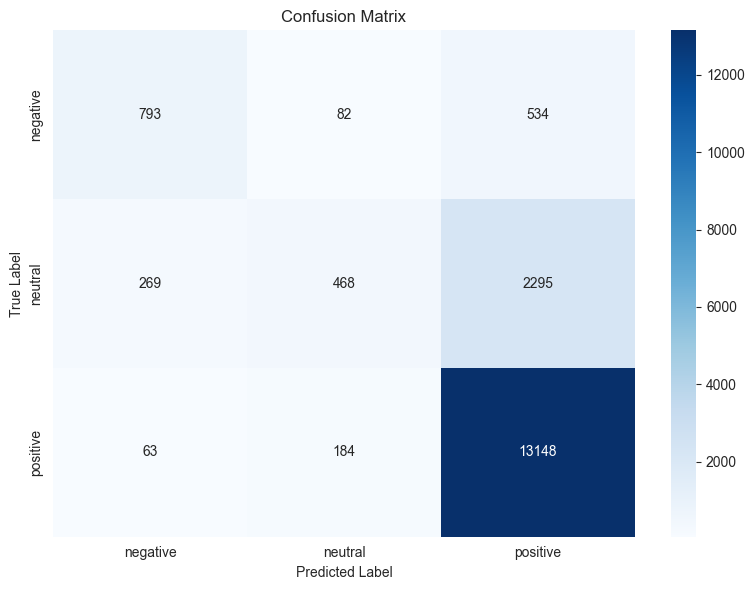

In [13]:
# ========================================
# Error Analysis Notebook
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import pickle

# Display settings
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("="*60)
print("ERROR ANALYSIS - Sentiment Analysis Model")
print("="*60)

# ========================================
# STEP 1: Load Data and Model
# ========================================
print("\nSTEP 1: Loading data and model...")

# Load preprocessed data
df = pd.read_csv('../data/processed/preprocessed_data.csv')
print(f"Total records: {len(df):,}")

# Load the best model
with open('../data/processed/best_model_svm.pkl', 'rb') as f:
    model = pickle.load(f)
print("Model loaded successfully")

# Load TF-IDF vectorizer
with open('../data/processed/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
print("TF-IDF vectorizer loaded successfully")

# ========================================
# STEP 2: Prepare Features (Same as Training)
# ========================================
print("\nSTEP 2: Preparing features...")

text_column = 'full_text_cleaned'
numerical_features = [
    'text_length', 'body_length', 'title_length', 'word_count',
    'has_advantages', 'has_disadvantages', 'likes', 'dislikes',
    'price_change_pct', 'product_popularity',
    'seller_avg_rate', 'seller_comment_count', 'seller_rate_std',
    'seller_total_likes', 'seller_total_dislikes', 'seller_like_ratio'
]

# Clean data
df_clean = df.dropna(subset=[text_column, 'sentiment_label']).copy()
df_clean[numerical_features] = df_clean[numerical_features].fillna(0)

# Fix product_popularity type
df_clean['product_popularity'] = pd.to_numeric(df_clean['product_popularity'], errors='coerce').fillna(0)

print(f"Clean dataset size: {len(df_clean):,}")

# ========================================
# STEP 3: Recreate Train-Test Split
# ========================================
print("\nSTEP 3: Recreating train-test split...")

from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix, hstack

X_text = df_clean[text_column]
X_numerical = df_clean[numerical_features]
y = df_clean['sentiment_label']

# Same split as training (same random_state=42)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, 
    X_numerical, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Test set size: {len(X_text_test):,}")

# Transform text with TF-IDF
X_text_test_tfidf = tfidf.transform(X_text_test)

# Convert numerical to sparse
X_num_test_sparse = csr_matrix(X_num_test.values)

# Combine features
X_test_combined = hstack([X_text_test_tfidf, X_num_test_sparse])

print(f"Test features shape: {X_test_combined.shape}")

# ========================================
# STEP 4: Generate Predictions
# ========================================
print("\nSTEP 4: Generating predictions...")

y_pred = model.predict(X_test_combined)

print("Predictions generated successfully")

# ========================================
# STEP 5: Overall Performance
# ========================================
print("\n" + "="*60)
print("STEP 5: Overall Performance Metrics")
print("="*60)

from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# Classification report
print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred, 
                          target_names=['negative', 'neutral', 'positive'],
                          digits=4))

# ========================================
# STEP 6: Confusion Matrix
# ========================================
print("\n" + "="*60)
print("STEP 6: Confusion Matrix Analysis")
print("="*60)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nConfusion matrix saved to: ../data/processed/confusion_matrix.png")
plt.show()

In [15]:
# ========================================
# STEP 7: Error Analysis (Fixed)
# ========================================
print("\n" + "="*60)
print("STEP 7: Detailed Error Analysis")
print("="*60)

# Get misclassified samples
misclassified_mask = (y_test.values != y_pred)
misclassified_count = misclassified_mask.sum()

print(f"\nTotal misclassified samples: {misclassified_count:,}")
print(f"Error rate: {misclassified_count / len(y_test) * 100:.2f}%")

# Errors by true class
print("\n" + "-"*60)
print("Errors by True Class:")
print("-"*60)

y_test_array = y_test.values
for label in [0, 1, 2]:
    label_name = ['negative', 'neutral', 'positive'][label]
    mask = (y_test_array == label) & misclassified_mask
    count = mask.sum()
    total = (y_test_array == label).sum()
    if total > 0:
        print(f"{label_name:>8}: {count:>4}/{total:>5} ({count/total*100:>5.2f}%)")

# Confusion patterns
print("\n" + "-"*60)
print("Confusion Patterns:")
print("-"*60)
for true_label in [0, 1, 2]:
    for pred_label in [0, 1, 2]:
        if true_label != pred_label:
            count = cm[true_label][pred_label]
            if count > 0:
                true_name = ['negative', 'neutral', 'positive'][true_label]
                pred_name = ['negative', 'neutral', 'positive'][pred_label]
                print(f"{true_name:>8} → {pred_name:<8}: {count:>4} samples")


STEP 7: Detailed Error Analysis

Total misclassified samples: 3,427
Error rate: 19.21%

------------------------------------------------------------
Errors by True Class:
------------------------------------------------------------

------------------------------------------------------------
Confusion Patterns:
------------------------------------------------------------
negative → neutral :   82 samples
negative → positive:  534 samples
 neutral → negative:  269 samples
 neutral → positive: 2295 samples
positive → negative:   63 samples
positive → neutral :  184 samples


In [19]:
# ========================================
# STEP 8: Sample Misclassified Examples (Fixed v4 - Correct!)
# ========================================
print("\n" + "="*60)
print("STEP 8: Sample Misclassified Examples")
print("="*60)

# Get test data with original text
test_indices = X_text_test.index
test_data = df_clean.loc[test_indices].copy()

# y_test is already string labels ('negative', 'neutral', 'positive')
# y_pred is also string labels
# No conversion needed!

test_data['true_label'] = y_test.values
test_data['predicted_label'] = y_pred

print(f"\nTrue label sample: {test_data['true_label'].head()}")
print(f"Predicted label sample: {test_data['predicted_label'].head()}")
print(f"True label unique: {test_data['true_label'].unique()}")
print(f"Predicted label unique: {test_data['predicted_label'].unique()}")

# Filter misclassified
misclassified_indices = np.where(misclassified_mask)[0]
error_df = test_data.iloc[misclassified_indices].copy()

print(f"\nTotal misclassified samples: {len(error_df):,}")

# Create pattern column
error_df['pattern'] = error_df['true_label'] + ' → ' + error_df['predicted_label']

print(f"\nPattern sample: {error_df['pattern'].head()}")
print(f"Pattern value counts:\n{error_df['pattern'].value_counts()}")

# Show examples for each pattern
patterns = error_df['pattern'].value_counts()
print(f"\nFound {len(patterns)} different error patterns")

# Determine available feature columns
display_cols = []
for col in ['text_length', 'word_count', 'likes', 'dislikes', 'cleaned_length', 'cleaned_word_count']:
    if col in error_df.columns:
        display_cols.append(col)

print(f"Available feature columns: {display_cols}\n")

for pattern in patterns.index[:6]:  # Top 6 patterns
    samples = error_df[error_df['pattern'] == pattern]
    print(f"\n{'='*60}")
    print(f"Pattern: {pattern} ({len(samples)} samples)")
    print('='*60)
    
    for idx, (_, row) in enumerate(samples.head(3).iterrows(), 1):
        print(f"\nExample {idx}:")
        text = str(row[text_column])[:200]
        print(f"Text: {text}...")
        print(f"True: {row['true_label']}")
        print(f"Predicted: {row['predicted_label']}")
        
        # Show available features
        if display_cols:
            feature_str = ", ".join([f"{col}: {row[col]}" for col in display_cols[:4]])
            print(f"Features: {feature_str}")
        print("-"*60)

print("\n" + "="*60)
print("Error Analysis Complete!")
print("="*60)

# ========================================
# STEP 9: Save Error Analysis Results
# ========================================
print("\n" + "="*60)
print("STEP 9: Saving Results")
print("="*60)

# Save misclassified samples
export_cols = [text_column, 'true_label', 'predicted_label', 'pattern'] + display_cols
error_df_export = error_df[export_cols].copy()
error_df_export.to_csv('../data/processed/misclassified_samples.csv', index=False, encoding='utf-8-sig')
print(f"\nMisclassified samples saved to: ../data/processed/misclassified_samples.csv")
print(f"Total misclassified samples saved: {len(error_df_export):,}")

# Summary statistics
print("\n" + "-"*60)
print("Summary by Pattern:")
print("-"*60)
for pattern, count in patterns.items():
    pct = count / len(error_df) * 100
    print(f"{pattern:>25}: {count:>4} ({pct:>5.1f}%)")

print("\n" + "="*60)
print("All analysis complete!")
print("="*60)



STEP 8: Sample Misclassified Examples

True label sample: 4758      neutral
28270    positive
61213    positive
74861    negative
6031     positive
Name: true_label, dtype: object
Predicted label sample: 4758     positive
28270    positive
61213    positive
74861    positive
6031     positive
Name: predicted_label, dtype: object
True label unique: ['neutral' 'positive' 'negative']
Predicted label unique: ['positive' 'neutral' 'negative']

Total misclassified samples: 3,427

Pattern sample: 4758      neutral → positive
74861    negative → positive
45402     neutral → positive
83634     neutral → positive
92978     neutral → positive
Name: pattern, dtype: object
Pattern value counts:
pattern
neutral → positive     2295
negative → positive     534
neutral → negative      269
positive → neutral      184
negative → neutral       82
positive → negative      63
Name: count, dtype: int64

Found 6 different error patterns
Available feature columns: ['text_length', 'word_count', 'likes', 'disli